<a href="https://colab.research.google.com/github/omarmkhallati/AI_For_Cybersecurity-Mkhallati/blob/main/Case_Study_Detecting_Suspicious_User_Behavior_Using_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Step 1. Import the Required Libraries**

Before building an anomaly detection model, we need to import the required Python libraries.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import IsolationForest

Explanation:

pandas is used to create and manipulate datasets.

matplotlib is used to visualize the results.

LabelEncoder converts categorical values into numbers.

IsolationForest is the machine learning algorithm used for anomaly detection.

**Step 2. Create the Dataset**

We first create a small dataset containing user activities.

In [ ]:
data = {
    'User':['U1','U2','U3','U4','U5',
            'U6','U7','U8','U9','U10'],

    'LoginHour':[8,9,8,10,9,
                 3,8,9,8,9],

    'FailedLogins':[0,1,0,0,0,
                    12,0,1,0,0],

    'FilesDownloaded':[15,18,20,12,17,
                       8200,16,19,14,18],

    'SessionMinutes':[420,390,410,380,400,
                      700,405,415,390,395],

    'UploadGB':[0.1,0.2,0.1,0.1,0.2,
                12.5,0.1,0.2,0.1,0.2],

    'NewDevice':['No','No','No','No','No',
                 'Yes','No','No','No','No'],

    'AdminAction':['No','No','No','No','No',
                   'Yes','No','No','No','No']
}

df = pd.DataFrame(data)

df

,User,LoginHour,FailedLogins,FilesDownloaded,SessionMinutes,UploadGB,NewDevice,AdminAction
0,U1,8,0,15,420,0.1,No,No
1,U2,9,1,18,390,0.2,No,No
2,U3,8,0,20,410,0.1,No,No
3,U4,10,0,12,380,0.1,No,No
4,U5,9,0,17,400,0.2,No,No
5,U6,3,12,8200,700,12.5,Yes,Yes
6,U7,8,0,16,405,0.1,No,No
7,U8,9,1,19,415,0.2,No,No
8,U9,8,0,14,390,0.1,No,No
9,U10,9,0,18,395,0.2,No,No


Explanation

Each row represents one user's activities.

The columns contain behavioral features such as:

Login hour, Failed login attempts, Number of downloaded files, Upload size, Administrative actions.

These features will be used by the machine learning model.

**Step 3. Encode Categorical Variables**

Machine learning algorithms cannot process text values such as Yes and No directly.

In [ ]:
encoder = LabelEncoder()
df['NewDevice'] = encoder.fit_transform(df['NewDevice'])
df['AdminAction'] = encoder.fit_transform(df['AdminAction'])

Explanation

The encoder converts text into numbers: No-->0, Yes-->1.

After encoding, the dataset contains only numerical values suitable for machine learning. Many scikit-learn algorithms require numerical inputs, so categorical variables must be encoded before training.

**Step 4. Select the Features**

The User column is only an identifier.

It should not be used for training.

In [ ]:
X = df.drop(columns=['User'])

Explanation

The model learns only from behavioral features.

The user IDs are kept separately for reporting results later.

**Step 5. Train the Isolation Forest**

In [ ]:
model = IsolationForest(
    contamination=0.1,
    random_state=42
)

model.fit(X)

IsolationForest(contamination=0.1, random_state=42)

Explanation

The model now learns what constitutes normal behavior.

Important parameters:

contamination = 0.1

This tells the algorithm that approximately 10% of users are expected to be anomalies.

Since our dataset contains 10 users, the model expects roughly one anomalous user.

Isolation Forest works by randomly partitioning the data. Observations that require fewer splits to isolate are considered more likely to be anomalies.

**Step 6. Predict Anomalies**

In [ ]:
df['Prediction'] = model.predict(X)

Explanation

The predictions are:1 for Normal user, -1 for Anomaly

The algorithm automatically classifies each user.

**Step 7. Calculate the Anomaly Scores**

In [ ]:
df['AnomalyScore'] = model.decision_function(X)

Explanation

Instead of simply saying

Normal

or

Anomaly

Isolation Forest also provides a numerical score.

Interpretation:

Larger values indicate more normal observations.

Lower (often negative) values indicate more abnormal observations.

The lower the score, the more suspicious the user is.

**Step 8. Display the Results**

In [ ]:
print(df[['User',
          'Prediction',
          'AnomalyScore']])

  User  Prediction  AnomalyScore
0   U1           1      0.111526
1   U2           1      0.077950
2   U3           1      0.124131
3   U4           1      0.029513
4   U5           1      0.144812
5   U6          -1     -0.265617
6   U7           1      0.166141
7   U8           1      0.065288
8   U9           1      0.127765
9  U10           1      0.152350


Explanation

The model identified User U6 as the anomaly because this user exhibits:

Very early login (3 AM), Twelve failed login attempts, Download of 8,200 files
Upload of 12.5 GB, Login from a new device, Administrative actions.

These behaviors differ significantly from those of the other users.

**Step 9. Visualize the Results**

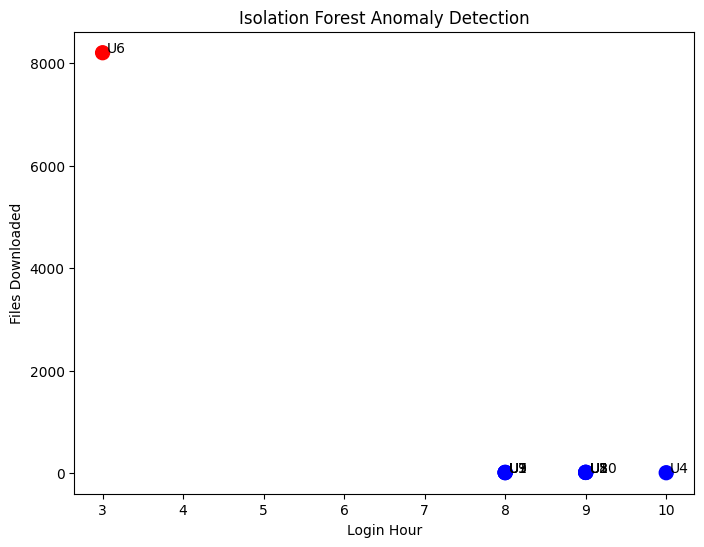

In [ ]:
plt.figure(figsize=(8,6))

colors = ['red' if p==-1 else 'blue'
          for p in df['Prediction']]

plt.scatter(
    df['LoginHour'],
    df['FilesDownloaded'],
    c=colors,
    s=100
)

for i,row in df.iterrows():
    plt.text(row['LoginHour']+0.05,
             row['FilesDownloaded'],
             row['User'])

plt.xlabel("Login Hour")
plt.ylabel("Files Downloaded")
plt.title("Isolation Forest Anomaly Detection")

plt.show()

Explanation

The scatter plot compares:

X-axis: Login Hour

Y-axis: Files Downloaded

Blue points represent normal users.

The red point represents the anomalous user.

Because U6 logged in much earlier than the others and downloaded an unusually large number of files, it appears clearly separated from the rest of the dataset.

**Step 10. Display Only the Detected Anomalies**

In [ ]:
anomalies = df[df['Prediction'] == -1]

print(anomalies)

  User  LoginHour  FailedLogins  FilesDownloaded  SessionMinutes  UploadGB  \
5   U6          3            12             8200             700      12.5   

   NewDevice  AdminAction  Prediction  AnomalyScore  
5          1            1          -1     -0.265617  


Explanation

The filtering operation displays only those users classified as anomalies.

This is similar to what happens in a Security Operations Center (SOC), where analysts focus their investigations on high-risk users instead of reviewing every employee.

**Final Interpretation**

The Isolation Forest model successfully identified User U6 as the anomalous user. Unlike supervised learning methods, Isolation Forest does not require labeled attack data. Instead, it learns the characteristics of normal user behavior and isolates observations that are substantially different from the rest of the dataset. This makes it particularly well suited for User Behavior Analytics (UBA), where organizations often have abundant normal activity logs but very few examples of confirmed attacks.

In a real enterprise environment, a Security Operations Center (SOC) would not immediately assume that U6 is malicious. Instead, the anomaly alert would trigger further investigation, including reviewing authentication logs, endpoint activity, network connections, and file access records before determining whether the account had been compromised or whether the unusual behavior had a legitimate business explanation.